# Part 1: Data Preprocessing

imports the main libraries used for data processing and plotting.

In [208]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

changes display settings and loads the three raw CSV files.

In [209]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

squirrel = pd.read_csv("squirrel.csv")
hectare = pd.read_csv("hectare.csv")
stories = pd.read_csv("stories.csv")

prints the size of each raw dataset.

In [210]:
print("squirrel shape:", squirrel.shape)
print("hectare shape:", hectare.shape)
print("stories shape:", stories.shape)

squirrel shape: (3023, 31)
hectare shape: (700, 13)
stories shape: (809, 12)


shows the first few rows of each raw dataset.

In [211]:
display(squirrel.head())
display(hectare.head())
display(stories.head())

,X,Y,Unique Squirrel ID,Hectare,Shift,Date,Hectare Squirrel Number,Age,Primary Fur Color,Highlight Fur Color,Combination of Primary and Highlight Color,Color notes,Location,Above Ground Sighter Measurement,Specific Location,Running,Chasing,Climbing,Eating,Foraging,Other Activities,Kuks,Quaas,Moans,Tail flags,Tail twitches,Approaches,Indifferent,Runs from,Other Interactions,Lat/Long
0,-73.956134,40.794082,37F-PM-1014-03,37F,PM,10142018,3,NaN,NaN,NaN,+,NaN,NaN,NaN,NaN,False,False,False,False,False,NaN,False,False,False,False,False,False,False,False,NaN,POINT (-73.9561344937861 40.7940823884086)
1,-73.968857,40.783783,21B-AM-1019-04,21B,AM,10192018,4,NaN,NaN,NaN,+,NaN,NaN,NaN,NaN,False,False,False,False,False,NaN,False,False,False,False,False,False,False,False,NaN,POINT (-73.9688574691102 40.7837825208444)
2,-73.974281,40.775534,11B-PM-1014-08,11B,PM,10142018,8,NaN,Gray,NaN,Gray+,NaN,Above Ground,10,NaN,False,True,False,False,False,NaN,False,False,False,False,False,False,False,False,NaN,POINT (-73.97428114848522 40.775533619083)
3,-73.959641,40.790313,32E-PM-1017-14,32E,PM,10172018,14,Adult,Gray,NaN,Gray+,Nothing selected as Primary. Gray selected as ...,NaN,NaN,NaN,False,False,False,True,True,NaN,False,False,False,False,False,False,False,True,NaN,POINT (-73.9596413903948 40.7903128889029)
4,-73.970268,40.776213,13E-AM-1017-05,13E,AM,10172018,5,Adult,Gray,Cinnamon,Gray+Cinnamon,NaN,Above Ground,NaN,on tree stump,False,False,False,False,True,NaN,False,False,False,False,False,False,False,False,NaN,POINT (-73.9702676472613 40.7762126854894)


,Hectare,Shift,Date,Anonymized Sighter,Sighter Observed Weather Data,Litter,Litter Notes,Other Animal Sightings,Hectare Conditions,Hectare Conditions Notes,Number of sighters,Number of Squirrels,Total Time of Sighting
0,01A,AM,10072018,110,"70º F, Foggy",Some,NaN,"Humans, Pigeons",Busy,NaN,1,4,22.0
1,01A,PM,10142018,177,"54º F, overcast",Abundant,NaN,"Humans, Pigeons",Busy,NaN,1,7,26.0
2,01B,AM,10122018,11,"60º F, sunny",Some,NaN,"Humans, Dogs, Pigeons, Horses",Busy,NaN,1,17,23.0
3,01B,PM,10192018,109,"59.8º F, Sun, Cool",Some,NaN,"Humans, Dogs, Pigeons, Sparrow, Blue jay",Busy,NaN,1,10,35.0
4,01C,PM,10132018,241,"55° F, Partly Cloudy",NaN,NaN,"Humans, Dogs, Pigeons, Birds",Busy,NaN,1,10,25.0


,Hectare,Shift,Date,Note Squirrel & Park Stories,Story Topic: Squirrel Experience or Squirrel Story,Story Topic: Park Experience or Census Taker Story,Story Topic: Dogs,Story Topic: Other Animals,Story Topic: Accidental Poems,Story Topic: Squirrels Acting Odd,Story Topic: Census Takers Recognized,Story Topic: Other
0,01A,PM,10142018,Observed a squirrel with a cache of peanuts th...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01A,AM,10182018,"Lots of pedestrians and vehicular traffic, foo...",NaN,True,NaN,NaN,NaN,NaN,NaN,NaN
2,01A,PM,10202018,Three of the pedicab drivers (14 pedicabs line...,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN
3,01A,AM,10072018,Squirrels were in surrounding grass areas/tree...,True,True,NaN,True,NaN,NaN,NaN,Birds
4,01B,AM,10122018,"""SQUIRREL APALOOZA""\n\n6+7 were playing on tre...",True,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Include indifferent responses

creates a human response variable for a stricter approach/avoid setup.

In [212]:
# Copy the data to keep the original dataset unchanged
df = squirrel.copy()

# Create a new target variable
df["Human_Response"] = np.nan

# Define Approach strictly
df.loc[
    (df["Approaches"] == True) &
    (df["Runs from"] == False) ,
    "Human_Response"
] = "Approach"
# Define Avoid strictly

# Keep only Approach and Avoid samples
df_interaction = df.dropna(subset=["Human_Response"]).copy()

C:\Users\wyh\AppData\Local\Temp\ipykernel_13832\302342212.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Approach' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[


counts each value in the new human response variable.

In [213]:
df["Human_Response"].value_counts(dropna=False)

Human_Response
NaN         2865
Approach     158
Name: count, dtype: int64

shows the proportion of each human response group.

In [214]:
df_interaction["Human_Response"].value_counts(normalize=True)

Human_Response
Approach    1.0
Name: proportion, dtype: float64

checks how many rows do not have a human response label.

In [215]:
nan_count = df["Human_Response"].isna().sum()
total_count = len(df)
nan_ratio = nan_count / total_count

print("Number of observations not included:", nan_count)
print("Total observations:", total_count)
print(f"Proportion not included: {nan_ratio:.3f}")

Number of observations not included: 2865
Total observations: 3023
Proportion not included: 0.948


counts missing values in the Indifferent column.

In [216]:
runs_from_counts = df["Indifferent"].isna().sum()
print(runs_from_counts)

0


creates the final target variable from the Approaches column.

In [217]:
df = squirrel.copy()

# Use the original Approaches column as the target
df["Approach_Target"] = df["Approaches"].astype(int)

df[["Approaches", "Approach_Target"]].head()

,Approaches,Approach_Target
0,False,0
1,False,0
2,False,0
3,False,0
4,False,0


summarizes how many squirrels approached and did not approach.

In [218]:
target_summary = (
    df["Approach_Target"]
    .value_counts()
    .rename_axis("Approach_Target")
    .reset_index(name="Count")
)

target_summary["Label"] = target_summary["Approach_Target"].map({
    0: "Did not approach",
    1: "Approached"
})

target_summary["Proportion"] = (
    target_summary["Count"] / target_summary["Count"].sum()
).round(3)

target_summary

,Approach_Target,Count,Label,Proportion
0,0,2845,Did not approach,0.941
1,1,178,Approached,0.059


plots the distribution of the approach target.

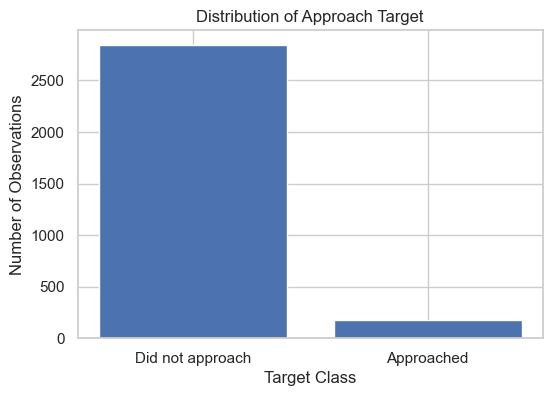

In [219]:
plt.figure(figsize=(6, 4))

plt.bar(
    target_summary["Label"],
    target_summary["Count"]
)

plt.title("Distribution of Approach Target")
plt.xlabel("Target Class")
plt.ylabel("Number of Observations")
plt.show()

Only 64 rows have missing Location values, so they are dropped.

checks how many observations belong to each Location value.

In [220]:
squirrel["Location"].value_counts(dropna=False)

Location
Ground Plane    2116
Above Ground     843
NaN               64
Name: count, dtype: int64

selects the useful columns and creates a binary column for Other Activities.

In [221]:
selected_cols = [
    "Shift",
    "Date",
    "Location",
    "Running",
    "Chasing",
    "Climbing",
    "Eating",
    "Foraging",
    "Other Activities",
    "Kuks",
    "Quaas",
    "Moans",
    "Tail flags",
    "Tail twitches",
    "Approaches"
]

df_selected = squirrel[selected_cols].copy()

# Drop rows where Location is missing and reset the index
df_selected = df_selected.dropna(subset=["Location"]).reset_index(drop=True)

# Process Other Activities
# NaN = 0, text = 1
df_selected["Has_Other_Activities"] = df_selected["Other Activities"].notna().astype(int)

# Drop the original text column
df_selected = df_selected.drop(columns=["Other Activities"])

# Reorder columns and place Has_Other_Activities before Approaches
df_selected = df_selected[
    [
        "Shift",
        "Date",
        "Location",
        "Running",
        "Chasing",
        "Climbing",
        "Eating",
        "Foraging",
        "Kuks",
        "Quaas",
        "Moans",
        "Tail flags",
        "Tail twitches",
        "Has_Other_Activities",
        "Approaches"
    ]
]

df_selected.head()

,Shift,Date,Location,Running,Chasing,Climbing,Eating,Foraging,Kuks,Quaas,Moans,Tail flags,Tail twitches,Has_Other_Activities,Approaches
0,PM,10142018,Above Ground,False,True,False,False,False,False,False,False,False,False,0,False
1,AM,10172018,Above Ground,False,False,False,False,True,False,False,False,False,False,0,False
2,AM,10102018,Ground Plane,False,False,False,False,True,False,False,False,False,False,0,False
3,AM,10082018,Ground Plane,False,False,False,False,True,False,False,False,False,False,0,False
4,PM,10062018,Ground Plane,False,False,False,False,False,False,False,False,True,True,0,False


converts the behavior and response columns into integers.

In [222]:
behavior_cols = [
    "Running",
    "Chasing",
    "Climbing",
    "Eating",
    "Foraging",
    "Kuks",
    "Quaas",
    "Moans",
    "Tail flags",
    "Tail twitches",
    "Has_Other_Activities",
    "Approaches"
]

df_selected[behavior_cols] = df_selected[behavior_cols].astype(int)

df_selected.head()

,Shift,Date,Location,Running,Chasing,Climbing,Eating,Foraging,Kuks,Quaas,Moans,Tail flags,Tail twitches,Has_Other_Activities,Approaches
0,PM,10142018,Above Ground,0,1,0,0,0,0,0,0,0,0,0,0
1,AM,10172018,Above Ground,0,0,0,0,1,0,0,0,0,0,0,0
2,AM,10102018,Ground Plane,0,0,0,0,1,0,0,0,0,0,0,0
3,AM,10082018,Ground Plane,0,0,0,0,1,0,0,0,0,0,0,0
4,PM,10062018,Ground Plane,0,0,0,0,0,0,0,0,1,1,0,0


confirms that no Location values are missing after cleaning.

In [223]:
df_selected["Location"].isna().sum()

np.int64(0)

Convert Date to day of week

converts the Date column into the day of the week.

In [224]:
date_str = df_selected["Date"].astype(str).str.zfill(8)

# 2. split month / day / year
date_parts = date_str.str.extract(r"(\d{2})(\d{2})(\d{4})")
date_parts.columns = ["month", "day", "year"]

# 3. transform to datetime
date_obj = pd.to_datetime(
    date_parts["month"] + "/" + date_parts["day"] + "/" + date_parts["year"],
    format="%m/%d/%Y",
    errors="coerce"
)

# 4. produce DAY_OF_WEEK
df_selected["DAY_OF_WEEK"] = date_obj.dt.day_name()

# 5. delete Date
df_selected = df_selected.drop(columns=["Date"])


new_col_order = [
    "Shift",
    "DAY_OF_WEEK",
    "Location",
    "Running",
    "Chasing",
    "Climbing",
    "Eating",
    "Foraging",
    "Kuks",
    "Quaas",
    "Moans",
    "Tail flags",
    "Tail twitches",
    "Has_Other_Activities",
    "Approaches"
]

df_selected = df_selected[new_col_order]

df_selected.head()

,Shift,DAY_OF_WEEK,Location,Running,Chasing,Climbing,Eating,Foraging,Kuks,Quaas,Moans,Tail flags,Tail twitches,Has_Other_Activities,Approaches
0,PM,Sunday,Above Ground,0,1,0,0,0,0,0,0,0,0,0,0
1,AM,Wednesday,Above Ground,0,0,0,0,1,0,0,0,0,0,0,0
2,AM,Wednesday,Ground Plane,0,0,0,0,1,0,0,0,0,0,0,0
3,AM,Monday,Ground Plane,0,0,0,0,1,0,0,0,0,0,0,0
4,PM,Saturday,Ground Plane,0,0,0,0,0,0,0,0,1,1,0,0


Convert day of week into separate columns

turns day of week into separate binary columns.

In [225]:
day_dummies = pd.get_dummies(df_selected["DAY_OF_WEEK"], prefix="Day", dtype=int)

df_selected = pd.concat(
    [df_selected.drop(columns=["DAY_OF_WEEK"]), day_dummies],
    axis=1
)

df_selected.head()

,Shift,Location,Running,Chasing,Climbing,Eating,Foraging,Kuks,Quaas,Moans,Tail flags,Tail twitches,Has_Other_Activities,Approaches,Day_Friday,Day_Monday,Day_Saturday,Day_Sunday,Day_Thursday,Day_Wednesday
0,PM,Above Ground,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1,AM,Above Ground,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
2,AM,Ground Plane,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
3,AM,Ground Plane,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
4,PM,Ground Plane,0,0,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0


Encode Shift and Location

encodes Shift and Location as numeric values.

In [226]:
# Shift: AM -> 0, PM -> 1
shift_map = {
    "AM": 0,
    "PM": 1
}

df_selected["Shift"] = df_selected["Shift"].map(shift_map)

# Location: Ground Plane -> 0, Above Ground -> 1
location_map = {
    "Ground Plane": 0,
    "Above Ground": 1
}

df_selected["Location"] = df_selected["Location"].map(location_map)

df_selected.head()

,Shift,Location,Running,Chasing,Climbing,Eating,Foraging,Kuks,Quaas,Moans,Tail flags,Tail twitches,Has_Other_Activities,Approaches,Day_Friday,Day_Monday,Day_Saturday,Day_Sunday,Day_Thursday,Day_Wednesday
0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
2,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0


saves the cleaned dataset as squirrel_processed.csv.

In [227]:
df_selected.to_csv("squirrel_processed.csv", index=False)

# Part 2: Correlation and Feature Analysis

imports libraries for correlation analysis, feature analysis, and classification models.

In [228]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.feature_selection import mutual_info_classif
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

loads the processed dataset and sets Approaches as the target variable.

In [229]:
df = pd.read_csv("squirrel_processed.csv")


# Target variable
target_col = "Approaches"

print(df.shape)
print(df.head())
print(df.columns)

(2959, 20)
   Shift  Location  Running  Chasing  Climbing  Eating  Foraging  Kuks  Quaas  \
0      1         1        0        1         0       0         0     0      0   
1      0         1        0        0         0       0         1     0      0   
2      0         0        0        0         0       0         1     0      0   
3      0         0        0        0         0       0         1     0      0   
4      1         0        0        0         0       0         0     0      0   

   Moans  Tail flags  Tail twitches  Has_Other_Activities  Approaches  \
0      0           0              0                     0           0   
1      0           0              0                     0           0   
2      0           0              0                     0           0   
3      0           0              0                     0           0   
4      0           1              1                     0           0   

   Day_Friday  Day_Monday  Day_Saturday  Day_Sunday  Day_Thursd

Correlation Analysis

creates scatter plots comparing each feature with the target variable.

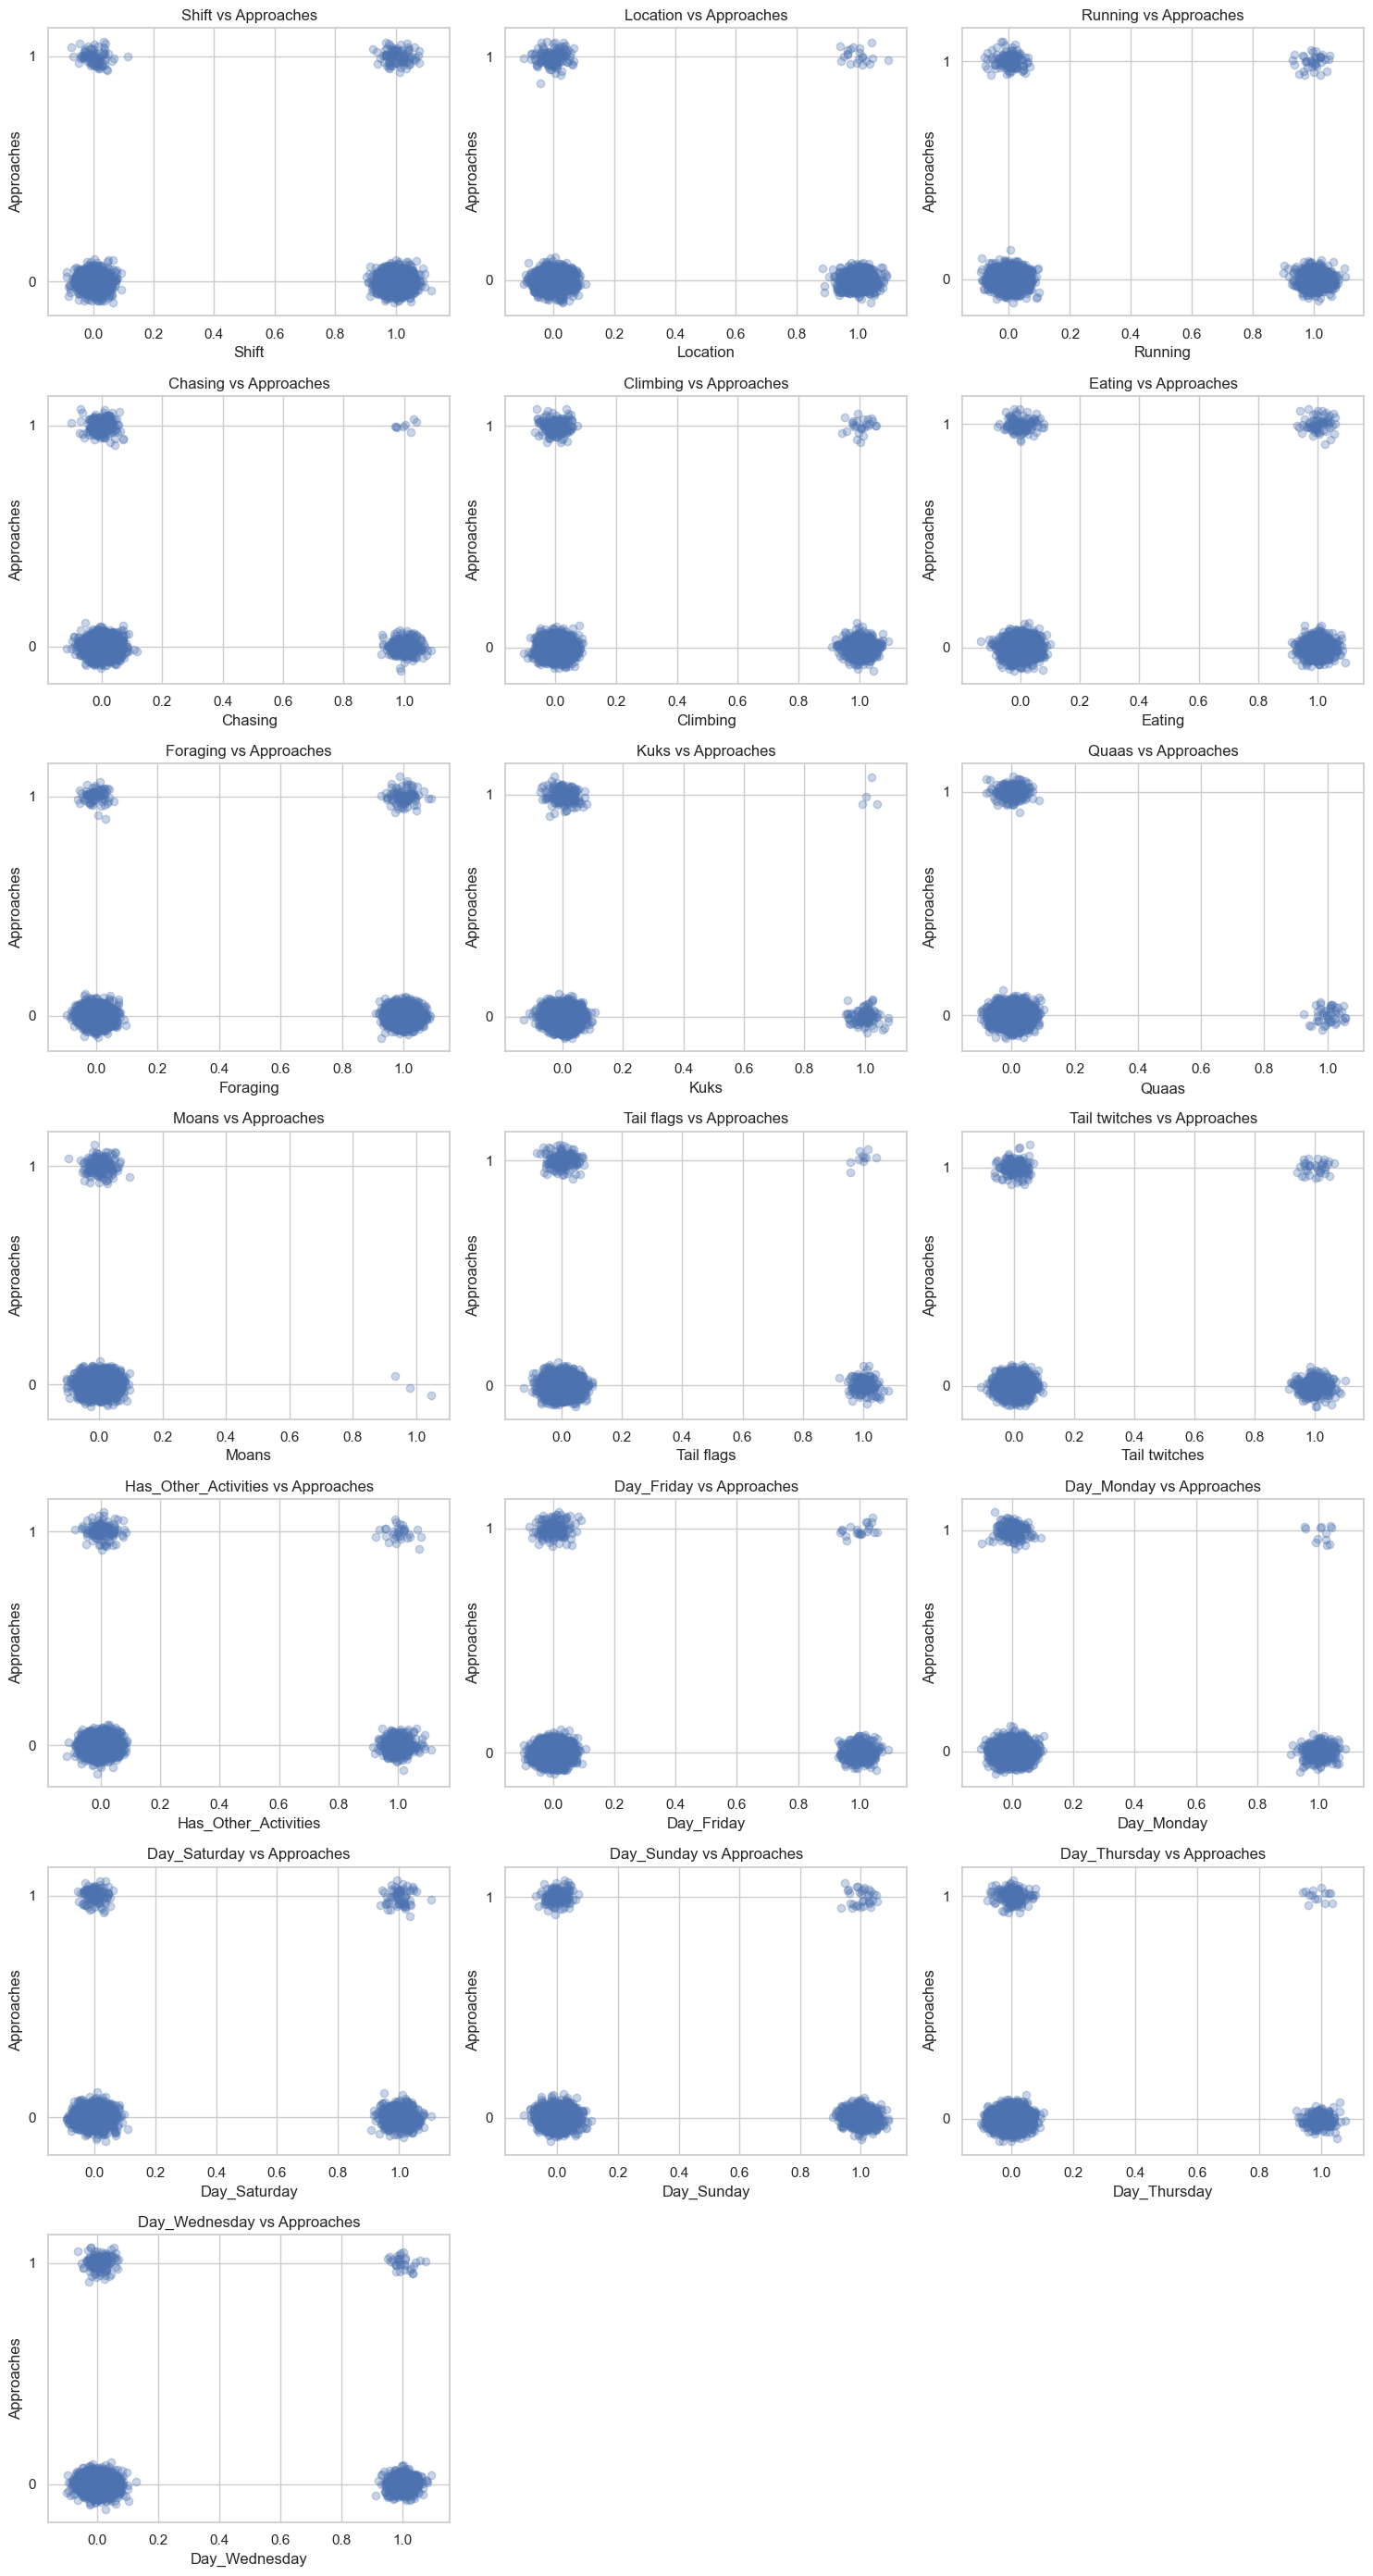

In [230]:
feature_cols = [col for col in df.columns if col != target_col]

n_cols = 3
n_rows = int(np.ceil(len(feature_cols) / n_cols))

plt.figure(figsize=(15, 4 * n_rows))

np.random.seed(42)

for i, col in enumerate(feature_cols, 1):
    x = df[col]
    y = df[target_col]

    x_jitter = x + np.random.normal(0, 0.03, size=len(x))
    y_jitter = y + np.random.normal(0, 0.03, size=len(y))

    plt.subplot(n_rows, n_cols, i)
    plt.scatter(x_jitter, y_jitter, alpha=0.3)

    plt.title(f"{col} vs {target_col}")
    plt.xlabel(col)
    plt.ylabel("Approaches")
    plt.yticks([0, 1], ["0", "1"])

plt.tight_layout()
plt.show()

Because the variables are binary, scatter plots are not very informative.

calculates Pearson correlations between the numeric features and Approaches.

In [231]:
# Keep numeric variables only
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Calculate Pearson correlation between each variable and Approaches
pearson_corr = numeric_df.corr()[target_col].drop(target_col)

# Sort by absolute correlation from largest to smallest
pearson_corr_sorted = pearson_corr.reindex(
    pearson_corr.abs().sort_values(ascending=False).index
)

print("Pearson correlation with Approaches:")
print(pearson_corr_sorted.round(3))

Pearson correlation with Approaches:
Location               -0.093
Eating                  0.073
Foraging                0.054
Day_Saturday            0.046
Climbing               -0.042
Chasing                -0.041
Day_Sunday             -0.039
Tail twitches           0.039
Quaas                  -0.032
Has_Other_Activities    0.026
Day_Monday             -0.023
Running                -0.017
Kuks                   -0.015
Day_Thursday            0.012
Moans                  -0.008
Shift                  -0.005
Tail flags              0.005
Day_Wednesday          -0.000
Day_Friday              0.000
Name: Approaches, dtype: float64


Pearson correlations are close to 0, so the linear relationships are weak.

finds which feature columns are binary variables.

In [232]:
binary_features = []

for col in df.columns:
    if col != target_col:
        values = set(df[col].dropna().unique())
        if values.issubset({0, 1}):
            binary_features.append(col)

print("Binary features:")
print(binary_features)

Binary features:
['Shift', 'Location', 'Running', 'Chasing', 'Climbing', 'Eating', 'Foraging', 'Kuks', 'Quaas', 'Moans', 'Tail flags', 'Tail twitches', 'Has_Other_Activities', 'Day_Friday', 'Day_Monday', 'Day_Saturday', 'Day_Sunday', 'Day_Thursday', 'Day_Wednesday']


compares approach rates when each binary feature is 0 versus 1.

In [233]:
rate_rows = []

for feature in binary_features:
    summary = df.groupby(feature)[target_col].agg(
        count="count",
        approach_count="sum",
        approach_rate="mean"
    )
    
    rate_0 = summary.loc[0, "approach_rate"] if 0 in summary.index else np.nan
    rate_1 = summary.loc[1, "approach_rate"] if 1 in summary.index else np.nan
    
    count_0 = summary.loc[0, "count"] if 0 in summary.index else 0
    count_1 = summary.loc[1, "count"] if 1 in summary.index else 0
    
    rate_rows.append({
        "Feature": feature,
        "Count_when_0": count_0,
        "Approach_rate_when_0": rate_0,
        "Count_when_1": count_1,
        "Approach_rate_when_1": rate_1,
        "Difference_1_minus_0": rate_1 - rate_0
    })

rate_df = pd.DataFrame(rate_rows)

# Sort by absolute difference
rate_df = rate_df.sort_values(
    "Difference_1_minus_0",
    key=lambda x: x.abs(),
    ascending=False
)

print(rate_df.round(3))

                 Feature  Count_when_0  Approach_rate_when_0  Count_when_1  \
8                  Quaas          2912                 0.061            47   
9                  Moans          2956                 0.060             3   
1               Location          2116                 0.074           843   
5                 Eating          2211                 0.050           748   
3                Chasing          2684                 0.063           275   
11         Tail twitches          2534                 0.056           425   
6               Foraging          1552                 0.048          1407   
15          Day_Saturday          2133                 0.053           826   
4               Climbing          2303                 0.065           656   
16            Day_Sunday          2208                 0.065           751   
7                   Kuks          2861                 0.060            98   
14            Day_Monday          2679                 0.062    

plots feature correlations with Approaches as a bar chart.

C:\Users\wyh\AppData\Local\Temp\ipykernel_13832\2800936091.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


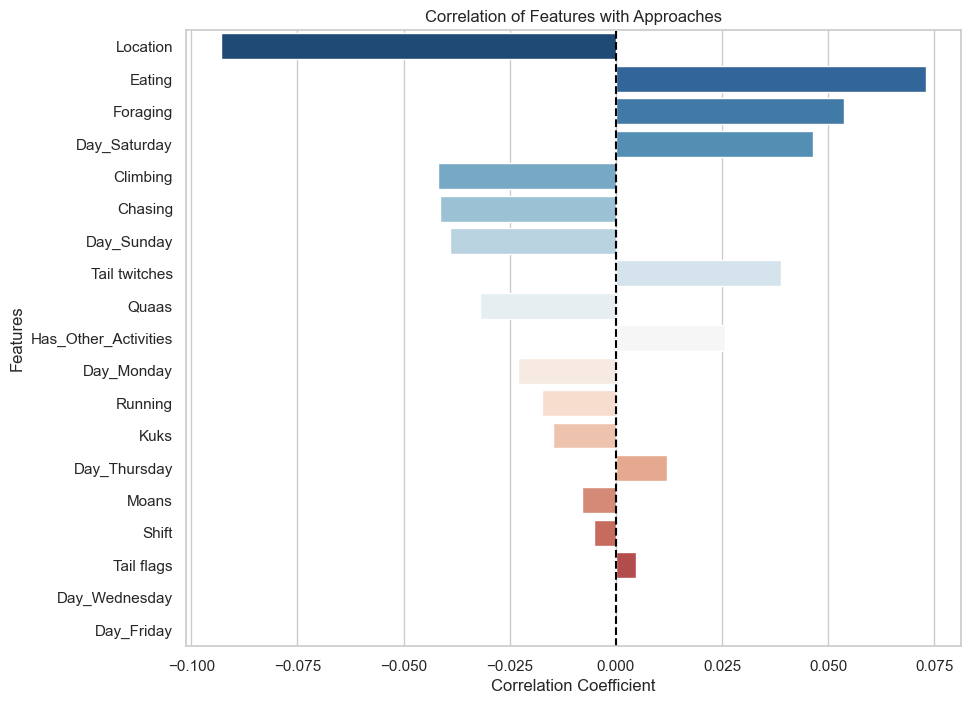

In [234]:
plt.figure(figsize=(10, 8))

sns.barplot(
    x=pearson_corr_sorted.values,
    y=pearson_corr_sorted.index,
    palette='RdBu_r'
)

plt.title('Correlation of Features with Approaches')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.axvline(x=0, color='black', linestyle='--')
plt.show()

creates a correlation heatmap for the numeric variables.

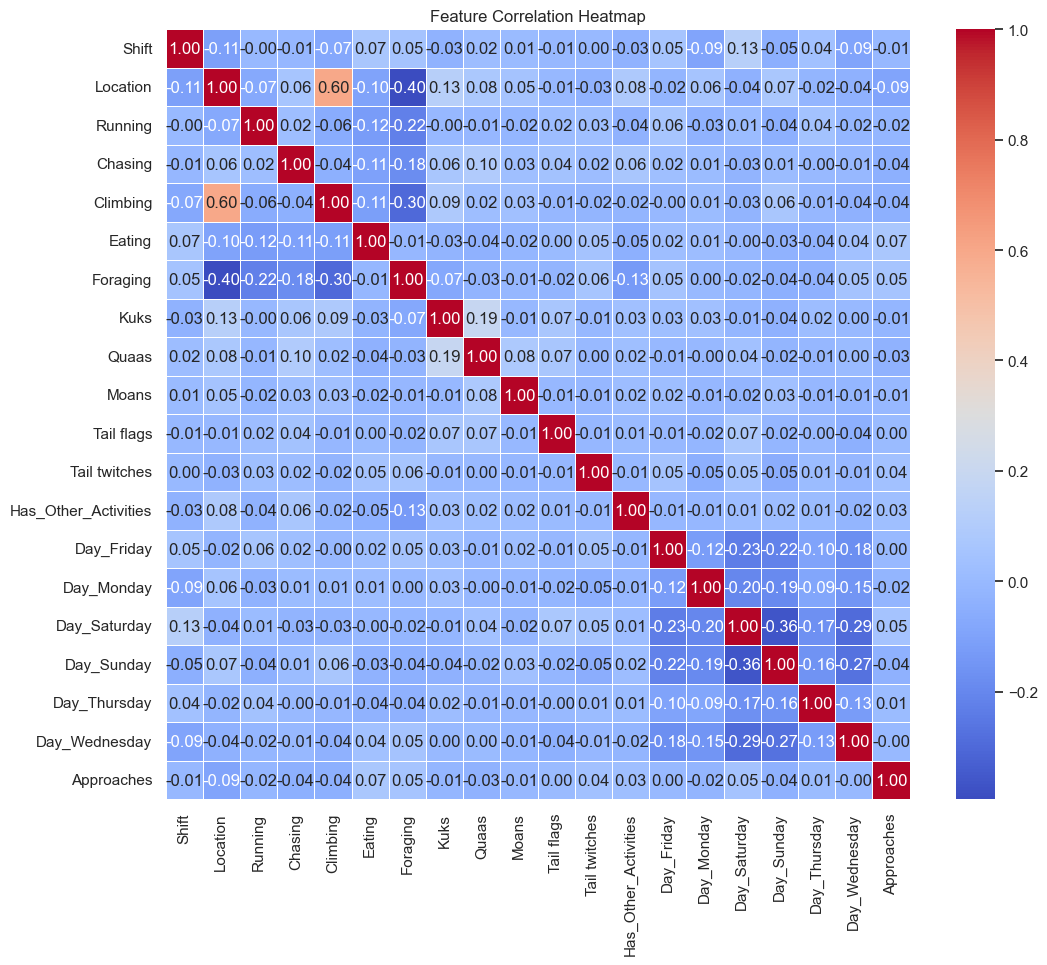

In [235]:
# X contains all features and y contains the target
X = df.drop(columns=[target_col])
y = df[target_col]

# Combine X and y for the correlation heatmap
plot_df = pd.concat([X, y], axis=1)

# Keep numeric variables only to avoid errors from non-numeric columns
plot_df = plot_df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(12, 10))

sns.heatmap(
    plot_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.show()

Mutual Information

calculates mutual information scores for behavior and day features.

In [236]:
behaviour_features = [
    "Running",
    "Chasing",
    "Climbing",
    "Eating",
    "Foraging",
    "Kuks",
    "Quaas",
    "Moans",
    "Tail flags",
    "Tail twitches",
    "Has_Other_Activities",
     "Day_Monday",
    "Day_Wednesday",
    "Day_Thursday",
    "Day_Friday",
    "Day_Saturday",
    "Day_Sunday"
]

# X contains the selected behavior and day features
X_mi = df[behaviour_features]

# y is the Approaches target
y_mi = df[target_col].astype(int)

# Calculate mutual information
mi_scores = mutual_info_classif(
    X_mi,
    y_mi,
    discrete_features=True,
    random_state=42
)

# Store the scores in a DataFrame
mi_df = pd.DataFrame({
    "Feature": behaviour_features,
    "Mutual_Information": mi_scores
})

# Sort by mutual information from largest to smallest
mi_df = mi_df.sort_values(
    by="Mutual_Information",
    ascending=False
)

print(mi_df.round(4))

                 Feature  Mutual_Information
3                 Eating              0.0025
4               Foraging              0.0014
1                Chasing              0.0010
15          Day_Saturday              0.0010
6                  Quaas              0.0010
2               Climbing              0.0010
16            Day_Sunday              0.0008
9          Tail twitches              0.0007
10  Has_Other_Activities              0.0003
11            Day_Monday              0.0003
0                Running              0.0002
5                   Kuks              0.0001
13          Day_Thursday              0.0001
7                  Moans              0.0001
8             Tail flags              0.0000
12         Day_Wednesday              0.0000
14            Day_Friday              0.0000


plots the mutual information scores.

C:\Users\wyh\AppData\Local\Temp\ipykernel_13832\1384052811.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


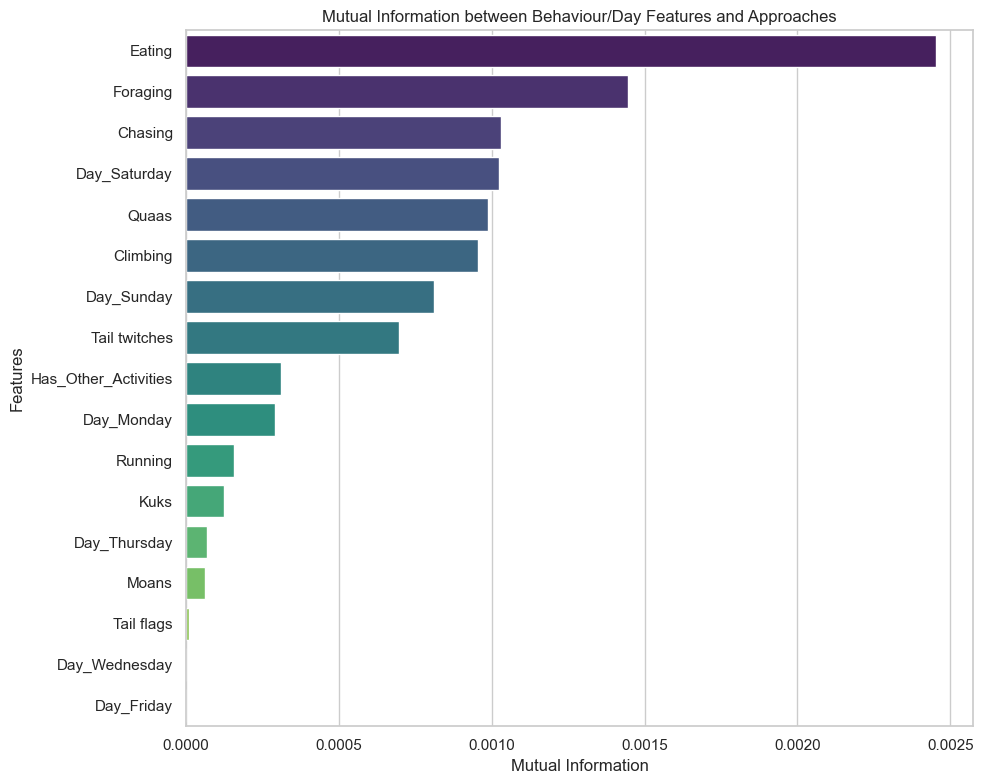

In [237]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=mi_df,
    x="Mutual_Information",
    y="Feature",
    palette="viridis"
)

plt.title("Mutual Information between Behaviour/Day Features and Approaches")
plt.xlabel("Mutual Information")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

plots how often each behavior appears in the dataset.

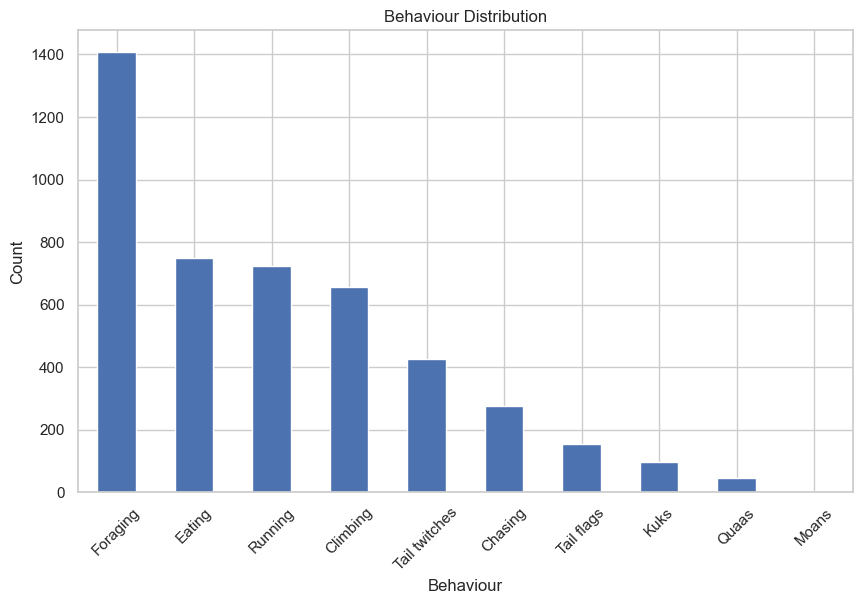

In [238]:
behavior_cols = [
    'Running',
    'Chasing',
    'Climbing',
    'Eating',
    'Foraging',
    'Kuks',
    'Quaas',
    'Moans',
    'Tail flags',
    'Tail twitches'
]

behavior_sum = df[behavior_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))

behavior_sum.plot(kind='bar')

plt.title("Behaviour Distribution")
plt.xlabel("Behaviour")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

# Part 3: KNN and Decision Tree Models

imports the libraries needed for the KNN and decision tree models.

In [239]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_score, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

import warnings

loads the processed dataset for modelling.

In [240]:
df = pd.read_csv('squirrel_processed.csv')

separates the input features from the target variable.

In [241]:
target_col = "Approaches"

feature_cols = [col for col in df.columns if col != target_col]

X = df[feature_cols]
y = df[target_col]

Split the data 8:2

splits the data into training and testing sets.

In [242]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

KNN

tests different K values for KNN using stratified cross-validation.

In [243]:
# Stratified 5-fold cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Candidate k values
k_values = [1, 3, 5, 7, 9, 11, 15, 21]

k_results = []

for k in k_values:
    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric="hamming"
    )

    scores = cross_val_score(
        knn,
        X_train,
        y_train,
        cv=cv,
        scoring="f1"
    )

    k_results.append({
        "k": k,
        "mean_cv_f1": scores.mean(),
        "std_cv_f1": scores.std()
    })

k_results_df = pd.DataFrame(k_results)

print(k_results_df)

    k  mean_cv_f1  std_cv_f1
0   1    0.074213   0.038498
1   3    0.010000   0.020000
2   5    0.012903   0.025806
3   7    0.000000   0.000000
4   9    0.000000   0.000000
5  11    0.000000   0.000000
6  15    0.000000   0.000000
7  21    0.000000   0.000000


trains the selected KNN model.

In [244]:
# Create and fit knn with k=5
knn = KNeighborsClassifier(n_neighbors=3)

# Fit to the train dataset
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


predicts the test set and prints the KNN accuracy.

In [245]:
y_pred_knn = knn.predict(X_test)

accuracy = knn.score(X_test, y_test)
print('Accuracy', accuracy)

Accuracy 0.9375


displays the KNN confusion matrix.

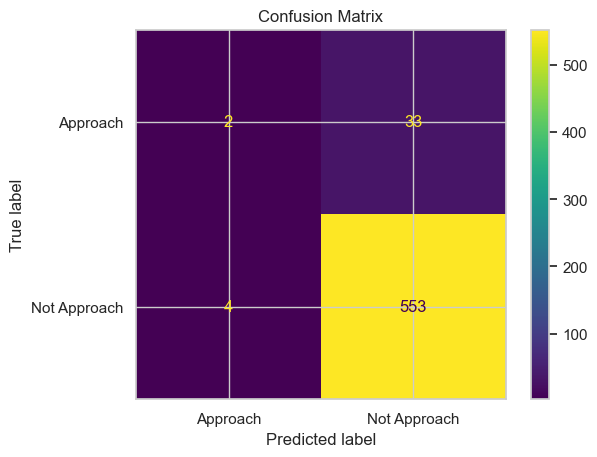

In [246]:
cm = confusion_matrix(y_test, # test data
                      y_pred_knn, # predictions
                      labels=[1, 0] # class labels from the knn model
                     )

disp = ConfusionMatrixDisplay(confusion_matrix=cm, # pass through the created confusion matrix
                              display_labels=['Approach', 'Not Approach'] # class labels from the knn model
                             )

disp.plot()

plt.title("Confusion Matrix")
plt.show()

prints the detailed KNN classification report.

In [247]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.94      0.99      0.97       557
           1       0.33      0.06      0.10        35

    accuracy                           0.94       592
   macro avg       0.64      0.52      0.53       592
weighted avg       0.91      0.94      0.92       592



Decision Tree

creates and trains a first decision tree model.

In [248]:
dt = DecisionTreeClassifier(
    criterion="entropy",
    class_weight = "balanced",
    random_state=42
)

# Fit to the training data
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curr

tests several decision tree settings using cross-validation.

In [249]:
# Do the manually tuning with Stratified CV
dt_results = []

for depth in [2, 3, 4, 5, 6, None]:
    for min_split in [2, 5, 10, 20]:
        for min_leaf in [1, 2, 5, 10]:

            dt = DecisionTreeClassifier(
                criterion="entropy",
                max_depth=depth,
                min_samples_split=min_split,
                min_samples_leaf=min_leaf,
                class_weight="balanced",
                random_state=42
            )

            scores = cross_val_score(
                dt,
                X_train,
                y_train,
                cv=cv,
                scoring="f1"
            )

            dt_results.append({
                "max_depth": depth,
                "min_samples_split": min_split,
                "min_samples_leaf": min_leaf,
                "mean_cv_f1": scores.mean(),
                "std_cv_f1": scores.std()
            })

dt_results_df = pd.DataFrame(dt_results)

dt_results_df = dt_results_df.sort_values("mean_cv_f1", ascending=False)
print(dt_results_df.head(10))

    max_depth  min_samples_split  min_samples_leaf  mean_cv_f1  std_cv_f1
91        NaN                 10                10    0.140805   0.023472
95        NaN                 20                10    0.140805   0.023472
87        NaN                  5                10    0.140805   0.023472
83        NaN                  2                10    0.140805   0.023472
60        5.0                 20                 1    0.137188   0.016129
61        5.0                 20                 2    0.137188   0.016129
50        5.0                  2                 5    0.137049   0.016243
54        5.0                  5                 5    0.137049   0.016243
62        5.0                 20                 5    0.137049   0.016243
58        5.0                 10                 5    0.137049   0.016243


trains the final decision tree model with the chosen settings.

In [250]:
dt_best = DecisionTreeClassifier(
    criterion="entropy",
    class_weight = "balanced",
    min_samples_leaf=10,
    min_samples_split=2,
    random_state=42
)

# Fit to the training data
dt_best.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the cur

plots the top levels of the decision tree.

[Text(0.5, 0.9, 'Location <= 0.5\nentropy = 1.0\nsamples = 2367\nvalue = [1183.5, 1183.5]\nclass = Not Approach'),
 Text(0.25, 0.7, 'Tail twitches <= 0.5\nentropy = 0.993\nsamples = 1706\nvalue = [842.014, 1025.144]\nclass = Approach'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'Running <= 0.5\nentropy = 0.998\nsamples = 1447\nvalue = [719.142, 791.778]\nclass = Approach'),
 Text(0.0625, 0.3, 'Eating <= 0.5\nentropy = 0.988\nsamples = 1063\nvalue = [522.336, 675.095]\nclass = Approach'),
 Text(0.03125, 0.1, '\n  (...)  \n'),
 Text(0.09375, 0.1, '\n  (...)  \n'),
 Text(0.1875, 0.3, 'Chasing <= 0.5\nentropy = 0.952\nsamples = 384\nvalue = [196.807, 116.683]\nclass = Not Approach'),
 Text(0.15625, 0.1, '\n  (...)  \n'),
 Text(0.21875, 0.1, '\n  (...)  \n'),
 Text(0.375, 0.5, 'Day_Friday <= 0.5\nentropy = 0.929\nsamples = 259\nvalue = [122.871, 233.366]\nclass = Approach'),
 Text(0.3125, 0.3, 'Running <= 0.5\nentropy = 0.908\nsamples = 212\nvalue = [99.467, 208.363]\nclass = Approach'

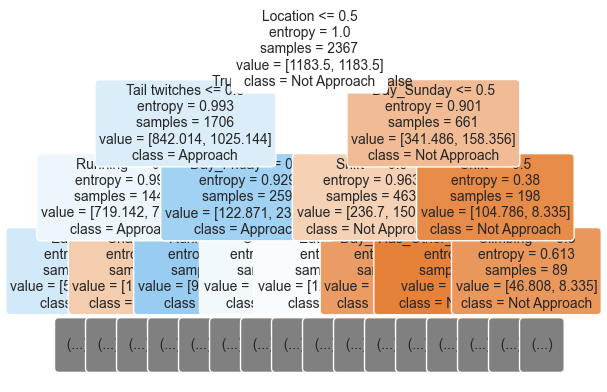

In [251]:
# Plot Decision Tree, but due to the overlapping, we just show first 3 levels
plot_tree(
    dt_best,
    feature_names=X.columns,
    class_names=["Not Approach", "Approach"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=10
)

predicts the test set and prints the decision tree accuracy.

In [252]:
y_pred_dt = dt_best.predict(X_test)

print("Accuracy:", dt_best.score(X_test, y_test))

Accuracy: 0.5945945945945946


prints the detailed decision tree classification report.

In [253]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.96      0.60      0.73       557
           1       0.08      0.57      0.14        35

    accuracy                           0.59       592
   macro avg       0.52      0.58      0.44       592
weighted avg       0.91      0.59      0.70       592



displays the decision tree confusion matrix.

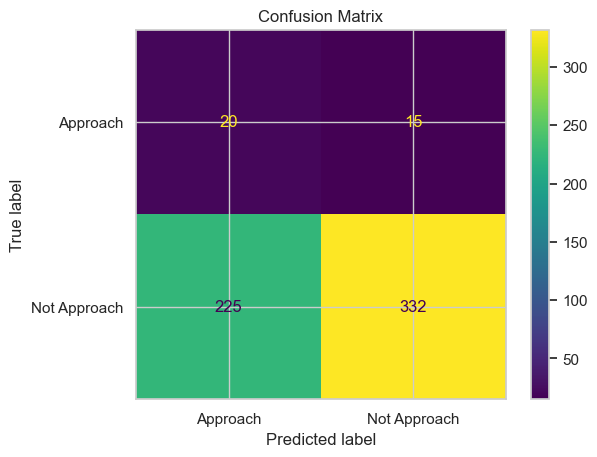

In [254]:
cm = confusion_matrix(y_test, # test data
                      y_pred_dt, # predictions
                      labels=[1, 0] # class labels from the knn model
                     )

disp = ConfusionMatrixDisplay(confusion_matrix=cm, # pass through the created confusion matrix
                              display_labels=['Approach', 'Not Approach'] # class labels from the knn model
                             )

disp.plot()

plt.title("Confusion Matrix")
plt.show()

calculates the feature importance values from the decision tree.

In [255]:
dt_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": dt_best.feature_importances_
}).sort_values("Importance", ascending=False)

print(dt_importance_df)

                 Feature  Importance
0                  Shift    0.146134
5                 Eating    0.107881
3                Chasing    0.096047
12  Has_Other_Activities    0.095782
16            Day_Sunday    0.093957
1               Location    0.089192
2                Running    0.058922
14            Day_Monday    0.054273
6               Foraging    0.053783
4               Climbing    0.052238
17          Day_Thursday    0.030999
18         Day_Wednesday    0.029542
10            Tail flags    0.028903
11         Tail twitches    0.023133
15          Day_Saturday    0.022317
13            Day_Friday    0.016897
9                  Moans    0.000000
7                   Kuks    0.000000
8                  Quaas    0.000000


plots the decision tree feature importance values.

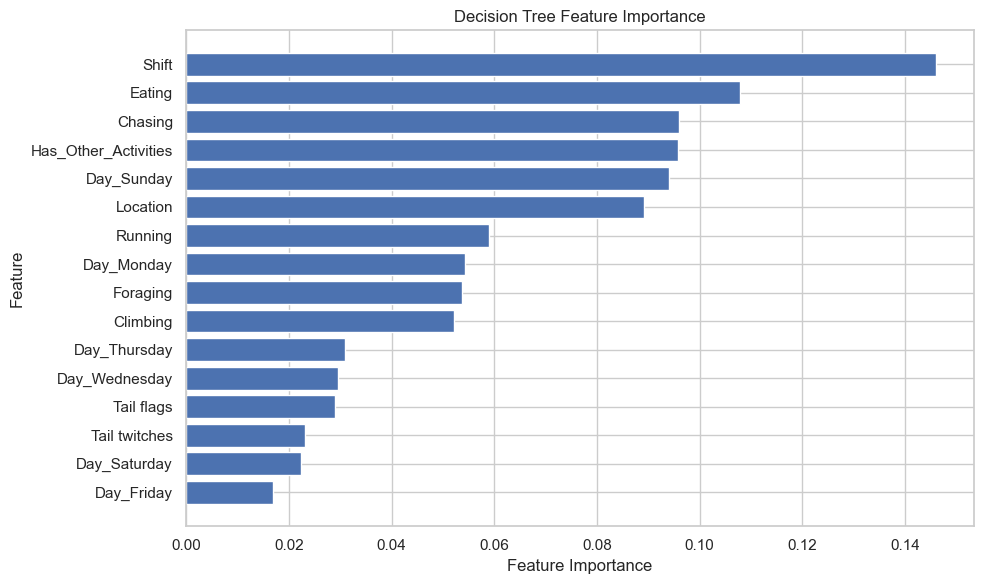

In [256]:
plt.figure(figsize=(10, 6))

# Plot the feature importance plot for DT
top_dt = dt_importance_df[dt_importance_df["Importance"] > 0] .sort_values("Importance")

plt.barh(top_dt["Feature"], top_dt["Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Decision Tree Feature Importance")
plt.tight_layout()
plt.show()

calculates KNN feature importance using permutation importance.

In [257]:
from sklearn.inspection import permutation_importance

knn_perm = permutation_importance(
    knn,
    X_test,
    y_test,
    n_repeats=30,
    random_state=42,
    scoring="f1"
)

knn_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance_mean": knn_perm.importances_mean,
    "Importance_std": knn_perm.importances_std
}).sort_values("Importance_mean", ascending=False)

print(knn_importance_df)

                 Feature  Importance_mean  Importance_std
16            Day_Sunday         0.076279        0.024362
0                  Shift         0.060746        0.029224
6               Foraging         0.052460        0.030171
15          Day_Saturday         0.028256        0.022751
2                Running         0.023946        0.030447
12  Has_Other_Activities         0.012871        0.020078
14            Day_Monday         0.010322        0.020499
5                 Eating         0.009251        0.051539
11         Tail twitches         0.008188        0.016442
8                  Quaas         0.001500        0.008586
4               Climbing         0.001028        0.036241
10            Tail flags         0.000860        0.023708
9                  Moans         0.000000        0.000000
3                Chasing        -0.000287        0.041737
7                   Kuks        -0.000565        0.025671
17          Day_Thursday        -0.003408        0.020257
18         Day

plots the most important KNN features.

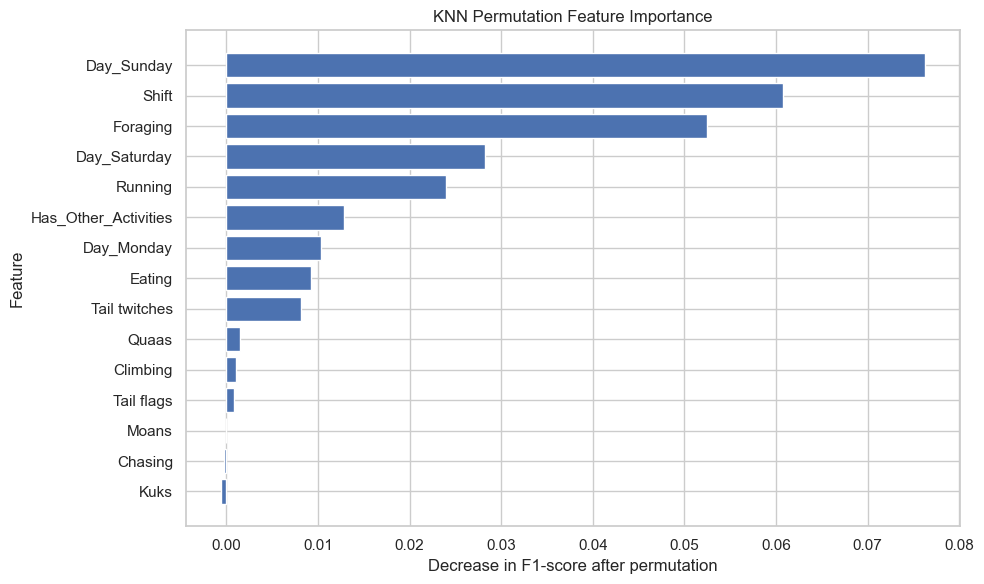

In [258]:
plt.figure(figsize=(10, 6))

# plot the feature importance plot for KNN
top_knn = knn_importance_df.sort_values("Importance_mean").tail(15)

plt.barh(
    top_knn["Feature"],
    top_knn["Importance_mean"]
)

plt.xlabel("Decrease in F1-score after permutation")
plt.ylabel("Feature")
plt.title("KNN Permutation Feature Importance")
plt.tight_layout()
plt.show()

# Part 4: Logistic Regression Model

makes the original Colab upload cell work in a local notebook.

In [259]:
# Local compatibility for the original Colab upload cell and filename typo.
from pathlib import Path
import sys
import types

if Path("squirrel_processed.csv").exists():
    Path("squirrel_processe.csv").write_bytes(Path("squirrel_processed.csv").read_bytes())

if "google.colab" not in sys.modules:
    google_module = sys.modules.setdefault("google", types.ModuleType("google"))
    colab_module = types.ModuleType("google.colab")

    class _LocalFiles:
        @staticmethod
        def upload():
            return {}

    colab_module.files = _LocalFiles()
    sys.modules["google.colab"] = colab_module

imports the libraries needed for logistic regression.

In [260]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_score, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

import warnings

loads the processed dataset for logistic regression.

In [261]:
from google.colab import files
updated = files.upload()
df = pd.read_csv("squirrel_processe.csv")

separates the logistic regression features and target variable.

In [262]:
target_col = "Approaches"

feature_cols = [col for col in df.columns if col != target_col]

X = df[feature_cols]
y = df[target_col]

splits the data into training and testing sets for logistic regression.

In [263]:
#split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (2367, 19)
Testing set shape: (592, 19)


trains logistic regression, evaluates it, and plots its results.

Accuracy:
0.6047297297297297
ROC-AUC:
0.6700179533213644
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.61      0.74       557
           1       0.08      0.57      0.15        35

    accuracy                           0.60       592
   macro avg       0.52      0.59      0.44       592
weighted avg       0.91      0.60      0.71       592



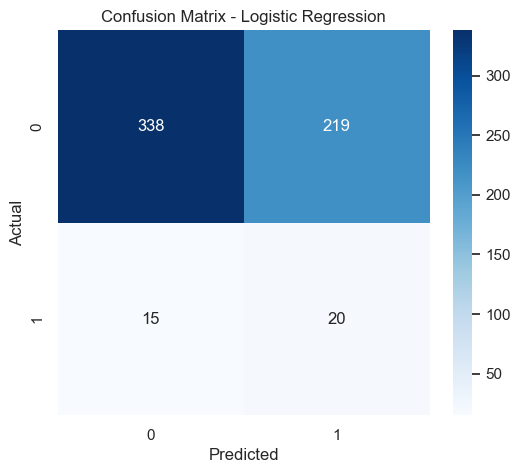

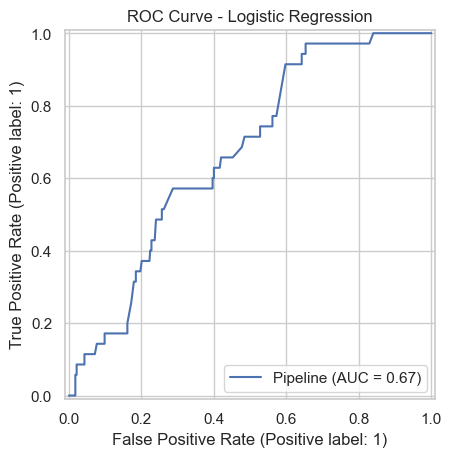

                 Feature  Coefficient
5                 Eating     0.273819
11         Tail twitches     0.181732
15          Day_Saturday     0.171208
12  Has_Other_Activities     0.121230
6               Foraging     0.119365
4               Climbing     0.114012
10            Tail flags     0.070445
17          Day_Thursday     0.061560
18         Day_Wednesday     0.021558
13            Day_Friday    -0.016518
14            Day_Monday    -0.020556
2                Running    -0.034087
7                   Kuks    -0.042991
3                Chasing    -0.099456
9                  Moans    -0.118965
0                  Shift    -0.145275
16            Day_Sunday    -0.206819
1               Location    -0.440419
8                  Quaas    -0.667332


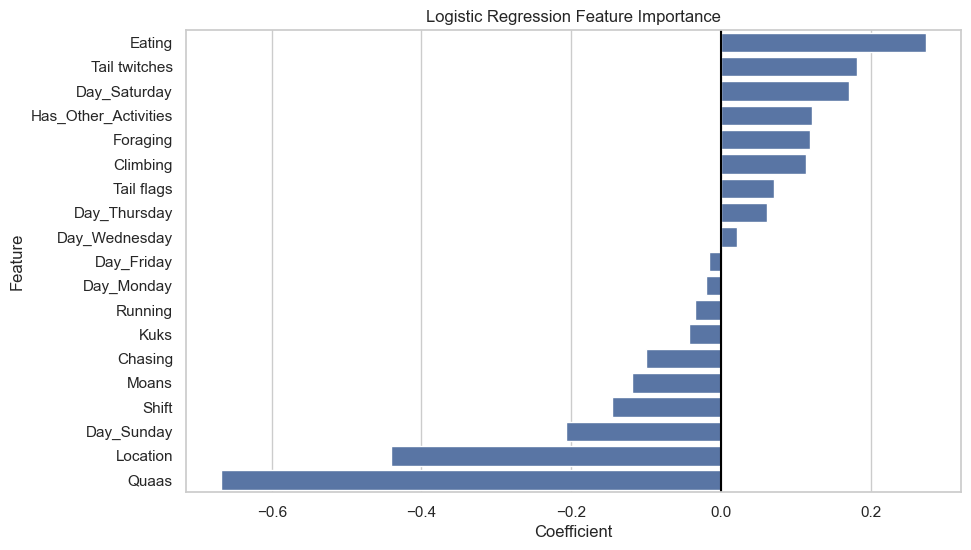

In [264]:
#Fit logistic regression
log_reg_model = Pipeline(steps=[

    ("scaler", StandardScaler()),

    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))

])

# Train Model
log_reg_model.fit(X_train, y_train)

# Prediction

y_pred_lr = log_reg_model.predict(X_test)

# Probability prediction
y_prob_lr = log_reg_model.predict_proba(X_test)[:,1]


# Accuracy
accuracy = accuracy_score(y_test, y_pred_lr)

print("Accuracy:")
print(accuracy)

# AUC
auc = roc_auc_score(y_test, y_prob_lr)

print("ROC-AUC:")
print(auc)

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_lr))

# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - Logistic Regression")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ROC Curve

RocCurveDisplay.from_estimator(
    log_reg_model,
    X_test,
    y_test
)

plt.title("ROC Curve - Logistic Regression")

plt.show()

# Feature Importance
# Get coefficients
coefficients = log_reg_model.named_steps[
    "classifier"
].coef_[0]

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coefficients
})

feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

print(feature_importance)

# Plot
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Coefficient",
    y="Feature"
)

plt.title("Logistic Regression Feature Importance")

plt.axvline(0, color='black')

plt.show()

# Part 5: Clustering Analysis

imports clustering libraries, sets constants, and creates the output folder.

In [265]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

%matplotlib inline

RANDOM_STATE = 42

sns.set_theme(style="whitegrid")
plt.ioff()

selects the features used for clustering.

In [266]:
df = pd.read_csv("squirrel_processed.csv")

behaviour_features = [
    "Running", "Chasing", "Climbing", "Eating", "Foraging",
    "Kuks", "Quaas", "Moans", "Tail flags", "Tail twitches",
    "Has_Other_Activities",
]

context_features = ["Location", "Shift"]
outcome_col = "Approaches"

required_cols = behaviour_features + context_features + [outcome_col]
df = df[required_cols]

shows the proportion of 1 values for each binary variable.

In [267]:
df[required_cols].mean().sort_values(ascending=False).to_frame("proportion")

,proportion
Shift,0.552552
Foraging,0.475498
Location,0.284894
Eating,0.252788
Running,0.244339
Climbing,0.221697
Has_Other_Activities,0.144981
Tail twitches,0.143630
Chasing,0.092937
Approaches,0.059818


runs the behavior-only clustering analysis.

In [268]:
X_behaviour = df[behaviour_features].astype(int).to_numpy()

rows = []
for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=50)
    labels = model.fit_predict(X_behaviour)
    sizes = pd.Series(labels).value_counts()
    rows.append({
        "k": k,
        "sse": model.inertia_,
        "min_cluster_size": sizes.min(),
        "max_cluster_size": sizes.max(),
    })

behaviour_k_metrics = pd.DataFrame(rows)

model = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=50)
behaviour_result = df.copy()
behaviour_result["Cluster"] = model.fit_predict(X_behaviour)

behaviour_profile = behaviour_result.groupby("Cluster")[behaviour_features + [outcome_col]].mean(numeric_only=True)
behaviour_profile.insert(0, "cluster_size", behaviour_result["Cluster"].value_counts().sort_index())
behaviour_profile["Approach_Rate"] = behaviour_profile[outcome_col]
behaviour_profile["Not_Approach_Rate"] = 1 - behaviour_profile["Approach_Rate"]

summary_rows = []
overall_means = df[behaviour_features].mean()
for cluster_id, values in behaviour_profile[behaviour_features].iterrows():
    difference = values - overall_means
    summary_rows.append({
        "Cluster": cluster_id,
        "high_features": ", ".join(difference.sort_values(ascending=False).head(3).index),
        "low_features": ", ".join(difference.sort_values(ascending=True).head(3).index),
    })

behaviour_summary = pd.DataFrame(summary_rows).set_index("Cluster")
behaviour_profile = behaviour_profile.join(behaviour_summary)


behaviour_k_metrics.round(4)

,k,sse,min_cluster_size,max_cluster_size
0,2,2796.7918,1407,1552
1,3,2375.7873,745,1161
2,4,2028.5980,664,914
3,5,1799.1457,334,846
4,6,1653.0676,239,824
5,7,1499.9336,168,727
6,8,1406.5187,168,800
7,9,1321.4687,127,800
8,10,1243.7581,98,726


plots the K selection results for behavior-only clustering.

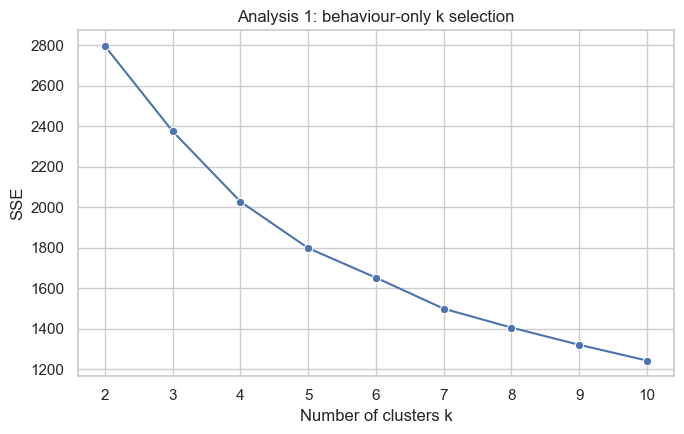

In [269]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.lineplot(data=behaviour_k_metrics, x="k", y="sse", marker="o", ax=ax)
ax.set_title("Analysis 1: behaviour-only k selection")
ax.set_xlabel("Number of clusters k")
ax.set_ylabel("SSE")
ax.set_xticks(behaviour_k_metrics["k"])
fig.tight_layout()
display(fig)
plt.close(fig)

displays the behavior-only cluster profiles.

In [270]:
behaviour_profile[[
    "cluster_size", "Approach_Rate", "Not_Approach_Rate",
    "high_features", "low_features"
]].round(3)

,cluster_size,Approach_Rate,Not_Approach_Rate,high_features,low_features
Cluster,,,,,
0,692,0.033,0.967,"Climbing, Chasing, Has_Other_Activities","Foraging, Eating, Running"
1,689,0.089,0.911,"Eating, Foraging, Tail twitches","Running, Climbing, Chasing"
2,664,0.051,0.949,"Running, Chasing, Tail flags","Foraging, Eating, Climbing"
3,914,0.065,0.935,"Foraging, Moans, Tail twitches","Eating, Running, Climbing"


plots a heatmap for the behavior-only cluster profiles.

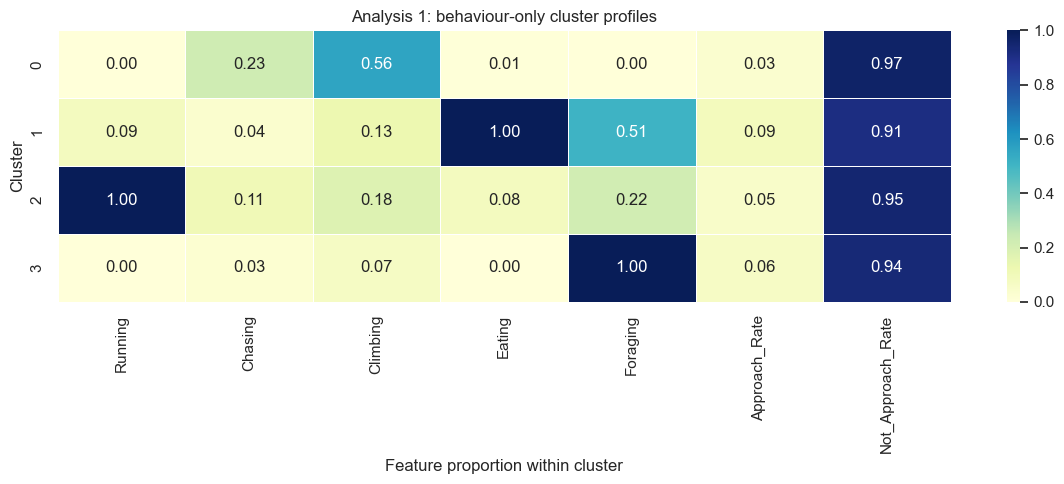

In [271]:
behaviour_heatmap_cols = [
    "Running", "Chasing", "Climbing", "Eating", "Foraging",
    "Approach_Rate", "Not_Approach_Rate",
]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    behaviour_profile[behaviour_heatmap_cols],
    annot=True,
    cmap="YlGnBu",
    fmt=".2f",
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Analysis 1: behaviour-only cluster profiles")
ax.set_xlabel("Feature proportion within cluster")
ax.set_ylabel("Cluster")
fig.tight_layout()
display(fig)
plt.close(fig)

plots the approach rate for each behavior-only cluster.

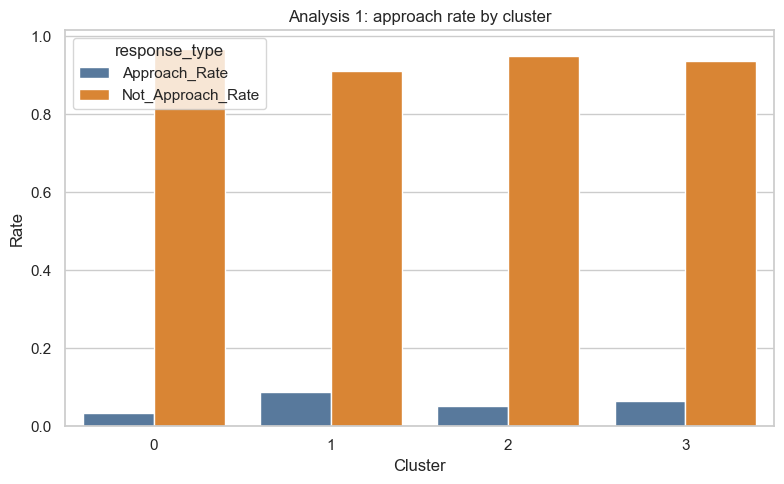

In [272]:
behaviour_response = behaviour_profile[["Approach_Rate", "Not_Approach_Rate"]].reset_index()
behaviour_response = behaviour_response.melt(
    id_vars="Cluster",
    var_name="response_type",
    value_name="rate",
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=behaviour_response,
    x="Cluster",
    y="rate",
    hue="response_type",
    palette=["#4C78A8", "#F58518"],
    ax=ax,
)
ax.set_title("Analysis 1: approach rate by cluster")
ax.set_xlabel("Cluster")
ax.set_ylabel("Rate")
fig.tight_layout()
display(fig)
plt.close(fig)

runs clustering with behavior, location, and shift features.

In [273]:
combined_features = behaviour_features + context_features
X_context = df[combined_features].astype(int).to_numpy()

rows = []
for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=50)
    labels = model.fit_predict(X_context)
    sizes = pd.Series(labels).value_counts()
    rows.append({
        "k": k,
        "sse": model.inertia_,
        "min_cluster_size": sizes.min(),
        "max_cluster_size": sizes.max(),
    })

context_k_metrics = pd.DataFrame(rows)

model = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=50)
context_result = df.copy()
context_result["Cluster"] = model.fit_predict(X_context)

context_profile = context_result.groupby("Cluster")[combined_features + [outcome_col]].mean(numeric_only=True)
context_profile.insert(0, "cluster_size", context_result["Cluster"].value_counts().sort_index())
context_profile["Approach_Rate"] = context_profile[outcome_col]
context_profile["Not_Approach_Rate"] = 1 - context_profile["Approach_Rate"]

summary_rows = []
overall_means = df[combined_features].mean()
for cluster_id, values in context_profile[combined_features].iterrows():
    difference = values - overall_means
    summary_rows.append({
        "Cluster": cluster_id,
        "high_features": ", ".join(difference.sort_values(ascending=False).head(3).index),
        "low_features": ", ".join(difference.sort_values(ascending=True).head(3).index),
    })

context_summary = pd.DataFrame(summary_rows).set_index("Cluster")
context_profile = context_profile.join(context_summary)


context_k_metrics.round(4)

,k,sse,min_cluster_size,max_cluster_size
0,2,4007.5233,871,2088
1,3,3437.7932,761,1328
2,4,3064.8526,629,988
3,5,2806.5470,459,775
4,6,2591.6065,337,565
5,7,2432.4101,323,564
6,8,2325.9528,251,552
7,9,2182.2856,238,510
8,10,2087.4807,185,484


plots the K selection results for the second clustering analysis.

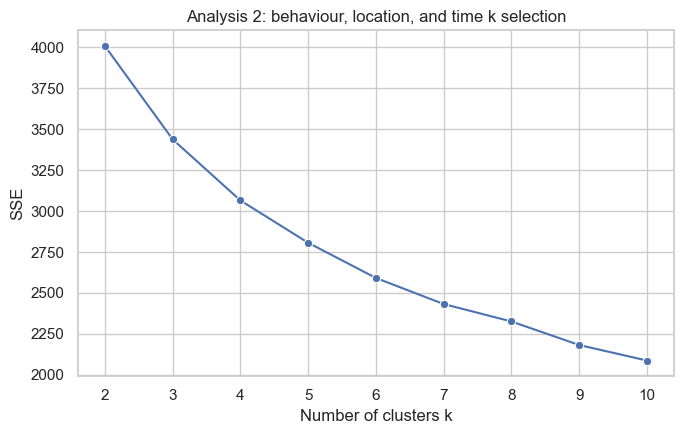

In [274]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.lineplot(data=context_k_metrics, x="k", y="sse", marker="o", ax=ax)
ax.set_title("Analysis 2: behaviour, location, and time k selection")
ax.set_xlabel("Number of clusters k")
ax.set_ylabel("SSE")
ax.set_xticks(context_k_metrics["k"])
fig.tight_layout()
display(fig)
plt.close(fig)

displays the cluster profiles for the second clustering analysis.

In [275]:
context_profile[[
    "cluster_size", "Approach_Rate", "Not_Approach_Rate",
    "Location", "Shift", "high_features", "low_features"
]].round(3)

,cluster_size,Approach_Rate,Not_Approach_Rate,Location,Shift,high_features,low_features
Cluster,,,,,,,
0,653,0.092,0.908,0.127,0.640,"Eating, Shift, Tail twitches","Climbing, Location, Running"
1,988,0.068,0.932,0.040,0.562,"Foraging, Shift, Tail twitches","Eating, Location, Climbing"
2,689,0.028,0.972,0.943,0.466,"Location, Climbing, Has_Other_Activities","Foraging, Eating, Running"
3,629,0.049,0.951,0.111,0.542,"Running, Chasing, Has_Other_Activities","Foraging, Eating, Location"


plots a heatmap for the second clustering analysis.

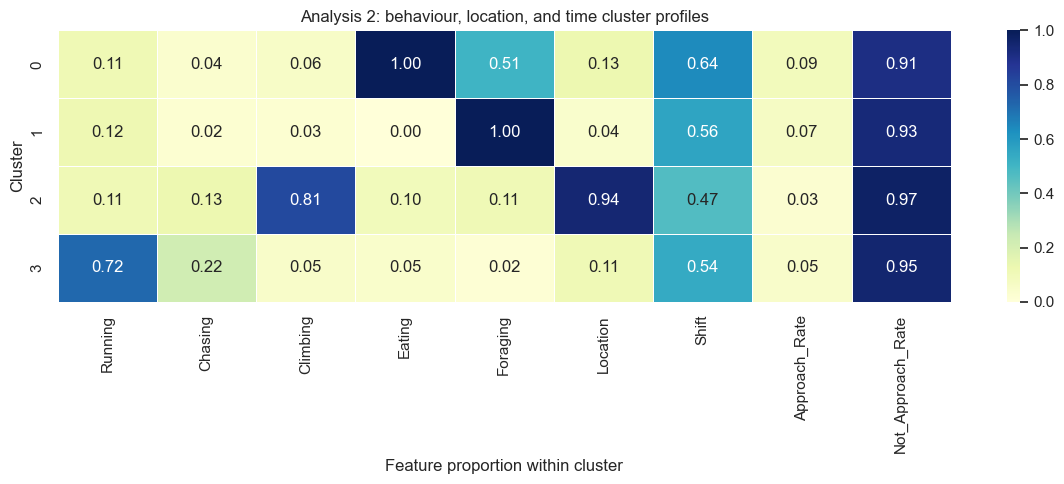

In [276]:
context_heatmap_cols = [
    "Running", "Chasing", "Climbing", "Eating", "Foraging",
    "Location", "Shift", "Approach_Rate", "Not_Approach_Rate",
]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    context_profile[context_heatmap_cols],
    annot=True,
    cmap="YlGnBu",
    fmt=".2f",
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Analysis 2: behaviour, location, and time cluster profiles")
ax.set_xlabel("Feature proportion within cluster")
ax.set_ylabel("Cluster")
fig.tight_layout()
display(fig)
plt.close(fig)

plots the approach rate for each cluster in the second analysis.

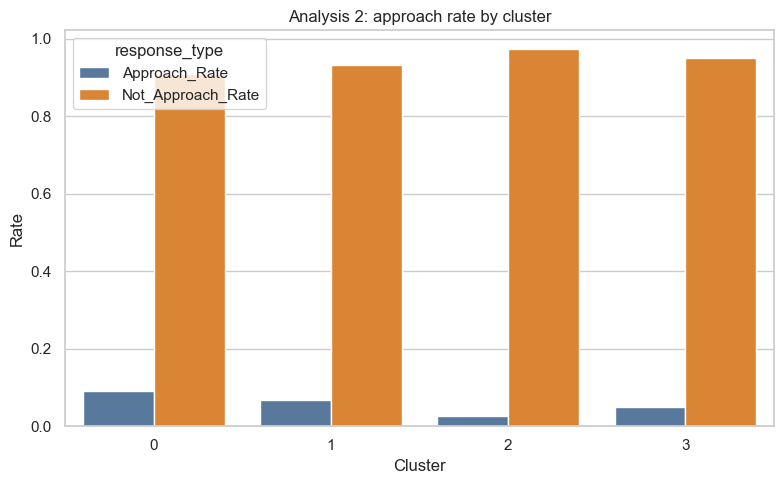

In [277]:
context_response = context_profile[["Approach_Rate", "Not_Approach_Rate"]].reset_index()
context_response = context_response.melt(
    id_vars="Cluster",
    var_name="response_type",
    value_name="rate",
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=context_response,
    x="Cluster",
    y="rate",
    hue="response_type",
    palette=["#4C78A8", "#F58518"],
    ax=ax,
)
ax.set_title("Analysis 2: approach rate by cluster")
ax.set_xlabel("Cluster")
ax.set_ylabel("Rate")
fig.tight_layout()
display(fig)
plt.close(fig)

creates PCA plots for both clustering analyses.

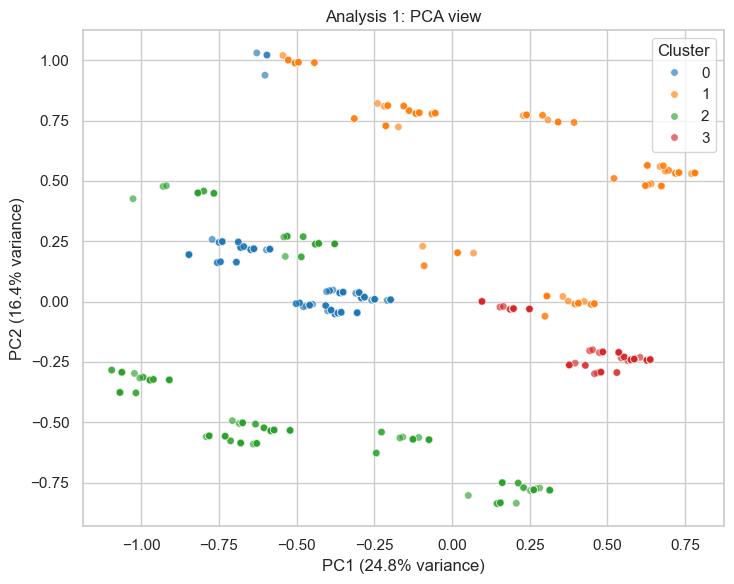

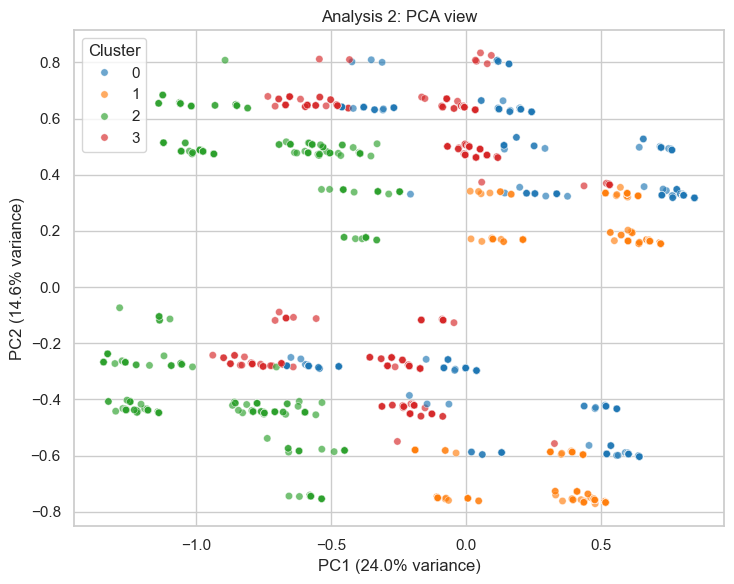

In [278]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_behaviour)
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": behaviour_result["Cluster"],
})

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    alpha=0.65,
    s=28,
    ax=ax,
)
ax.set_title("Analysis 1: PCA view")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
fig.tight_layout()
display(fig)
plt.close(fig)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_context)
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": context_result["Cluster"],
})

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    alpha=0.65,
    s=28,
    ax=ax,
)
ax.set_title("Analysis 2: PCA view")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
fig.tight_layout()
display(fig)
plt.close(fig)